# Reinforcement Learning Foundations with a 7×7 GridWorld

Reinforcement learning studies how an **agent** makes sequential decisions by interacting with an **environment** and receiving feedback through rewards.

This notebook uses one deterministic 7×7 GridWorld to build the main concepts step by step. The focus is on understanding the mathematical objects that later RL algorithms use rather than training a learning algorithm.

### Topics

- Markov Decision Processes
- State, action, transition, and reward
- Agent–environment interaction
- Policy
- Return and discount factor
- State-value and action-value functions
- Bellman expectation equation
- Bellman optimality equation
- Exploration vs. exploitation

## 1. Imports and Reproducibility

A fixed random seed is used whenever random actions are sampled so that the demonstrations can be reproduced.

In [2]:
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Define the GridWorld Environment

The environment is a deterministic 7×7 grid.

- **Start state:** `(0, 0)`
- **Goal state:** `(6, 6)`
- **Obstacles:** `(2, 2)`, `(3, 3)`, `(4, 4)`, `(5, 2)`, `(1, 5)`
- **Actions:** `Up`, `Down`, `Left`, `Right`
- **Regular move:** reward `-1`
- **Obstacle attempt:** remain in the current state and receive `-5`
- **Goal:** receive `+10` and terminate the episode
- **Boundary attempt:** remain in the current state and receive the regular step reward `-1`

Obstacle cells are not valid states because the agent can never occupy them.

Two interfaces are provided:

- `transition(state, action)` evaluates a transition without changing the environment.
- `step(action)` performs the transition from the agent's current state.

In [3]:
class GridworldMDP:
    def __init__(self, size=7, gamma=0.9):
        self.size = size
        self.gamma = gamma

        self.start_state = (0, 0)
        self.goal_state = (6, 6)
        self.obstacles = {(2, 2), (3, 3), (4, 4), (5, 2), (1, 5)}
        self.action_space = ("Up", "Down", "Left", "Right")

        # Valid states include every grid cell except obstacles.
        self.state_space = [
            (row, col)
            for row in range(size)
            for col in range(size)
            if (row, col) not in self.obstacles
        ]

        self.state = self.start_state

    def reset(self, state=None):
        # Reset to the default start state or to a supplied valid state.
        if state is None:
            state = self.start_state

        if state not in self.state_space:
            raise ValueError("Reset state must be a valid non-obstacle state.")

        self.state = state
        return self.state

    def transition(self, state, action):
        # Pure transition model: it does not modify self.state.
        if state not in self.state_space:
            raise ValueError("State must be a valid non-obstacle state.")

        if action not in self.action_space:
            raise ValueError("Invalid action.")

        # Once the goal is reached, the episode is over.
        if state == self.goal_state:
            return self.goal_state, 0, True

        row, col = state

        if action == "Up":
            candidate = (max(row - 1, 0), col)
        elif action == "Down":
            candidate = (min(row + 1, self.size - 1), col)
        elif action == "Left":
            candidate = (row, max(col - 1, 0))
        else:  # Right
            candidate = (row, min(col + 1, self.size - 1))

        # Attempting to enter an obstacle leaves the agent in place.
        if candidate in self.obstacles:
            return state, -5, False

        # Reaching the goal terminates the episode.
        if candidate == self.goal_state:
            return candidate, 10, True

        # A regular move or boundary attempt receives the step cost.
        return candidate, -1, False

    def transition_probability(self, state, action, next_state):
        # The environment is deterministic: the realized next state has probability 1.
        realized_state, _, _ = self.transition(state, action)
        return 1.0 if next_state == realized_state else 0.0

    def step(self, action):
        # Apply the transition to the current environment state.
        next_state, reward, done = self.transition(self.state, action)
        self.state = next_state
        return next_state, reward, done

    def plot(self, state=None, title="7×7 GridWorld"):
        # Visualize the environment with Matplotlib.
        if state is None:
            state = self.state

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xlim(-0.5, self.size - 0.5)
        ax.set_ylim(self.size - 0.5, -0.5)
        ax.set_xticks(range(self.size))
        ax.set_yticks(range(self.size))
        ax.set_xticks(np.arange(-0.5, self.size, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, self.size, 1), minor=True)
        ax.grid(which="minor", linewidth=1)
        ax.tick_params(which="minor", bottom=False, left=False)

        for row in range(self.size):
            for col in range(self.size):
                position = (row, col)

                if position in self.obstacles:
                    label = "X"
                elif position == self.goal_state:
                    label = "G"
                elif position == self.start_state:
                    label = "S"
                else:
                    label = ""

                if label:
                    ax.text(col, row, label, ha="center", va="center", fontsize=14)

        if state != self.goal_state:
            ax.text(state[1], state[0], "A", ha="center", va="center", fontsize=14)

        ax.set_xlabel("Column")
        ax.set_ylabel("Row")
        ax.set_title(title)
        plt.show()

Number of grid cells: 49
Number of obstacle cells: 5
Number of valid states: 44
Action space: ('Up', 'Down', 'Left', 'Right')
Start state: (0, 0)
Goal state: (6, 6)
Obstacles: [(1, 5), (2, 2), (3, 3), (4, 4), (5, 2)]


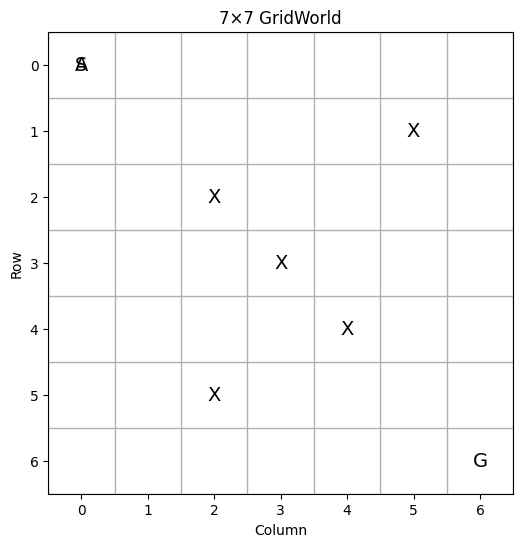

In [4]:
env = GridworldMDP(gamma=0.9)

print("Number of grid cells:", env.size * env.size)
print("Number of obstacle cells:", len(env.obstacles))
print("Number of valid states:", len(env.state_space))
print("Action space:", env.action_space)
print("Start state:", env.start_state)
print("Goal state:", env.goal_state)
print("Obstacles:", sorted(env.obstacles))

env.plot()

## 3. Markov Decision Process

A Markov Decision Process is commonly represented by

$$
\mathcal{M}=(\mathcal{S},\mathcal{A},P,R,\gamma)
$$

For this GridWorld:

- $\mathcal{S}$: all valid grid positions  
- $\mathcal{A}$: `Up`, `Down`, `Left`, `Right`  
- $P(s'|s,a)$: probability of reaching $s'$ after taking action $a$ in state $s$  
- $R(s,a,s')$: immediate reward for the transition  
- $\gamma$: discount factor controlling the weight placed on future rewards

Because the environment is deterministic, exactly one next state has transition probability 1 for a given state–action pair. Every other next state has probability 0.

In [5]:
example_state = (2, 1)
example_action = "Right"

next_state, reward, done = env.transition(example_state, example_action)

print("Current state:", example_state)
print("Action:", example_action)
print("Next state:", next_state)
print("Reward:", reward)
print("Terminal:", done)
print("P(next_state | state, action):",
      env.transition_probability(example_state, example_action, next_state))
print("P((2, 0) | state, action):",
      env.transition_probability(example_state, example_action, (2, 0)))

Current state: (2, 1)
Action: Right
Next state: (2, 1)
Reward: -5
Terminal: False
P(next_state | state, action): 1.0
P((2, 0) | state, action): 0.0


The action `Right` from `(2, 1)` attempts to enter obstacle `(2, 2)`. The agent therefore stays at `(2, 1)` and receives the obstacle penalty.

This single example exposes both the transition model and reward model:

$$
P((2,1)\mid (2,1),\text{Right})=1
$$

$$
R((2,1),\text{Right},(2,1))=-5
$$

### 3.1 Boundary and Goal Transitions

The environment can be queried directly for other cases as well. This avoids inserting manually assumed numbers into the explanation.

In [6]:
examples = [
    ((0, 0), "Up", "Boundary attempt"),
    ((2, 1), "Right", "Obstacle attempt"),
    ((5, 6), "Down", "Goal transition"),
]

for state, action, description in examples:
    next_state, reward, done = env.transition(state, action)
    probability = env.transition_probability(state, action, next_state)

    print(description)
    print(f"  {state} --{action}--> {next_state}")
    print(f"  Reward = {reward}, P = {probability}, Terminal = {done}")
    print()

Boundary attempt
  (0, 0) --Up--> (0, 0)
  Reward = -1, P = 1.0, Terminal = False

Obstacle attempt
  (2, 1) --Right--> (2, 1)
  Reward = -5, P = 1.0, Terminal = False

Goal transition
  (5, 6) --Down--> (6, 6)
  Reward = 10, P = 1.0, Terminal = True



## 4. The Markov Property

The Markov property states that the next-state distribution depends on the **current state and current action**, not on the complete history that led to that state.

$$
P(S_{t+1}\mid S_t,A_t,S_{t-1},A_{t-1},\ldots)
=
P(S_{t+1}\mid S_t,A_t)
$$

In this deterministic GridWorld, the same state–action pair always produces the same next state and reward.

In [7]:
state = (4, 5)
action = "Down"

result_1 = env.transition(state, action)
result_2 = env.transition(state, action)

print("First evaluation:", result_1)
print("Second evaluation:", result_2)
print("Same result:", result_1 == result_2)

First evaluation: ((5, 5), -1, False)
Second evaluation: ((5, 5), -1, False)
Same result: True


## 5. Agent–Environment Interaction

At each decision step:

1. The agent observes state $S_t$.
2. It selects action $A_t$.
3. The environment returns reward $R_{t+1}$.
4. The environment moves to state $S_{t+1}$.
5. The process repeats until a terminal state is reached.

The following demonstration uses a **random policy**. It is only an interaction example; no learning occurs.

In [8]:
def random_policy(env):
    return np.random.choice(env.action_space)

env.reset()
trajectory = []

for step_number in range(1, 13):
    state = env.state
    action = random_policy(env)
    next_state, reward, done = env.step(action)

    trajectory.append((step_number, state, action, reward, next_state, done))

    if done:
        break

print(f"{'Step':<6}{'State':<12}{'Action':<8}{'Reward':<9}{'Next State':<12}{'Done'}")
for row in trajectory:
    step_number, state, action, reward, next_state, done = row
    print(f"{step_number:<6}{str(state):<12}{action:<8}{reward:<9}{str(next_state):<12}{done}")

Step  State       Action  Reward   Next State  Done
1     (0, 0)      Left    -1       (0, 0)      False
2     (0, 0)      Right   -1       (0, 1)      False
3     (0, 1)      Up      -1       (0, 1)      False
4     (0, 1)      Left    -1       (0, 0)      False
5     (0, 0)      Left    -1       (0, 0)      False
6     (0, 0)      Right   -1       (0, 1)      False
7     (0, 1)      Up      -1       (0, 1)      False
8     (0, 1)      Up      -1       (0, 1)      False
9     (0, 1)      Left    -1       (0, 0)      False
10    (0, 0)      Down    -1       (1, 0)      False
11    (1, 0)      Left    -1       (1, 0)      False
12    (1, 0)      Left    -1       (1, 0)      False


## 6. Policy

A policy describes how an agent chooses actions.

A stochastic policy is written as

$$
\pi(a|s)=P(A_t=a\mid S_t=s)
$$

Two common forms are:

- **Deterministic policy:** one action is selected for each state.
- **Stochastic policy:** a probability distribution is defined over the available actions.

A uniform random policy assigns equal probability to all four actions:

$$
\pi(a|s)=\frac{1}{4}=0.25
$$

In [9]:
def uniform_random_policy(env, state):
    return {action: 1.0 / len(env.action_space) for action in env.action_space}

def simple_deterministic_policy(env, state):
    # A demonstration policy: move down until the last row, then move right.
    if state == env.goal_state:
        return None
    if state[0] < env.goal_state[0]:
        return "Down"
    return "Right"

sample_state = (3, 1)

print("State:", sample_state)
print("Uniform random policy:", uniform_random_policy(env, sample_state))
print("Example deterministic policy:", simple_deterministic_policy(env, sample_state))

State: (3, 1)
Uniform random policy: {'Up': 0.25, 'Down': 0.25, 'Left': 0.25, 'Right': 0.25}
Example deterministic policy: Down


A policy does not need to be optimal. It only needs to define how actions are selected. Value functions are always interpreted relative to a policy unless they are explicitly described as optimal value functions.

## 7. Return and Discount Factor

The **return** is the discounted sum of future rewards:

$$
G_t
=
R_{t+1}
+\gamma R_{t+2}
+\gamma^2R_{t+3}
+\cdots
$$

where

$$
0\leq\gamma\leq1
$$

is the discount factor.

To make the calculation concrete, the rewards below are obtained directly from a valid GridWorld path rather than typed manually.

In [10]:
def run_action_sequence(env, start_state, actions):
    state = env.reset(start_state)
    rewards = []

    for action in actions:
        next_state, reward, done = env.step(action)
        rewards.append(reward)
        state = next_state

        if done:
            break

    return rewards, state

actions = ["Down", "Down", "Down"]
rewards, final_state = run_action_sequence(env, start_state=(3, 6), actions=actions)

print("Start state:", (3, 6))
print("Actions:", actions)
print("Rewards generated by the model:", rewards)
print("Final state:", final_state)

Start state: (3, 6)
Actions: ['Down', 'Down', 'Down']
Rewards generated by the model: [-1, -1, 10]
Final state: (6, 6)


In [11]:
def discounted_return(rewards, gamma):
    return sum((gamma ** t) * reward for t, reward in enumerate(rewards))

for gamma in [0.0, 0.5, 0.9, 1.0]:
    G = discounted_return(rewards, gamma)
    print(f"gamma = {gamma:>3}: G = {G:.3f}")

gamma = 0.0: G = -1.000
gamma = 0.5: G = 1.000
gamma = 0.9: G = 6.200
gamma = 1.0: G = 8.000


For this trajectory, the goal reward occurs after two regular step penalties. A larger $\gamma$ gives that delayed goal reward more influence on the current return.

- $\gamma=0$: only the immediate reward matters.
- $0<\gamma<1$: future rewards matter but are discounted.
- $\gamma=1$: rewards are not discounted.

## 8. State-Value Function $V^\pi(s)$

The state-value function measures how good it is to be in a state while following policy $\pi$:

$$
V^\pi(s)=\mathbb{E}_\pi[G_t \mid S_t=s]
$$

For a fixed policy, the Bellman expectation relationship can be applied repeatedly until the state values stop changing.

Here the evaluated policy is the **uniform random policy**. This gives actual values for the current GridWorld while keeping the focus on the meaning of $V^\pi(s)$. It is not an optimal-control calculation.


In [12]:
def evaluate_uniform_random_policy(env, gamma=0.9, tolerance=1e-10, max_iterations=10000):
    values = {state: 0.0 for state in env.state_space}
    action_probability = 1.0 / len(env.action_space)

    for iteration in range(1, max_iterations + 1):
        new_values = values.copy()
        delta = 0.0

        for state in env.state_space:
            if state == env.goal_state:
                new_values[state] = 0.0
                continue

            state_value = 0.0

            for action in env.action_space:
                next_state, reward, done = env.transition(state, action)
                future_value = 0.0 if done else values[next_state]
                state_value += action_probability * (
                    reward + gamma * future_value
                )

            new_values[state] = state_value
            delta = max(delta, abs(state_value - values[state]))

        values = new_values

        if delta < tolerance:
            return values, iteration

    raise RuntimeError("Policy evaluation did not converge.")

V_random, sweeps = evaluate_uniform_random_policy(env, gamma=0.9)

print("Policy-evaluation sweeps:", sweeps)
print(f"V^pi(0, 0) = {V_random[(0, 0)]:.3f}")
print(f"V^pi(2, 1) = {V_random[(2, 1)]:.3f}")
print(f"V^pi(5, 6) = {V_random[(5, 6)]:.3f}")
print(f"V^pi(6, 5) = {V_random[(6, 5)]:.3f}")
print(f"V^pi(6, 6) = {V_random[(6, 6)]:.3f}")

Policy-evaluation sweeps: 216
V^pi(0, 0) = -11.787
V^pi(2, 1) = -14.243
V^pi(5, 6) = -2.263
V^pi(6, 5) = -2.399
V^pi(6, 6) = 0.000


### 8.1 Visualize $V^\pi(s)$

Higher values indicate states with better expected long-term return under the same policy. Obstacle cells are marked with `X`, and the terminal goal is marked with `G`.

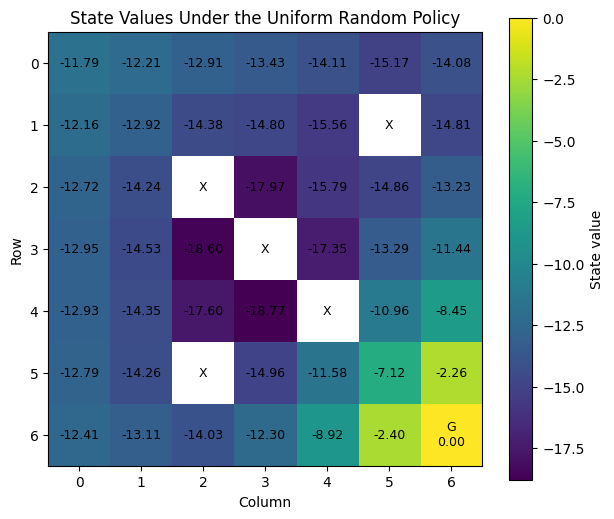

In [13]:
def plot_state_values(env, values, title):
    value_grid = np.full((env.size, env.size), np.nan)

    for state, value in values.items():
        value_grid[state] = value

    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(value_grid)

    for row in range(env.size):
        for col in range(env.size):
            state = (row, col)

            if state in env.obstacles:
                label = "X"
            elif state == env.goal_state:
                label = "G\n0.00"
            else:
                label = f"{values[state]:.2f}"

            ax.text(col, row, label, ha="center", va="center", fontsize=9)

    ax.set_xticks(range(env.size))
    ax.set_yticks(range(env.size))
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="State value")
    plt.show()

plot_state_values(
    env,
    V_random,
    "State Values Under the Uniform Random Policy"
)

## 9. Action-Value Function $Q^\pi(s,a)$

The action-value function measures the expected return after taking action $a$ in state $s$ and then following policy $\pi$:

$$
Q^\pi(s,a)=\mathbb{E}_\pi[G_t\mid S_t=s,A_t=a]
$$

Because the transition model is deterministic, once $V^\pi$ is known,

$$
Q^\pi(s,a)=R(s,a,s')+\gamma V^\pi(s')
$$

for non-terminal transitions. If $s'$ is terminal, there is no future value after the terminal reward.


In [14]:
def q_from_state_values(env, values, state, action, gamma=0.9):
    next_state, reward, done = env.transition(state, action)
    future_value = 0.0 if done else values[next_state]
    q_value = reward + gamma * future_value
    return q_value, next_state, reward, done

q_demo_state = (5, 6)
q_values = {}

for action in env.action_space:
    q_value, next_state, reward, done = q_from_state_values(
        env,
        V_random,
        q_demo_state,
        action,
        gamma=0.9
    )
    q_values[action] = q_value

    print(
        f"{action:<5} -> next_state={next_state}, "
        f"reward={reward:>2}, done={str(done):<5}, "
        f"Q^pi={q_value:.3f}"
    )

Up    -> next_state=(4, 6), reward=-1, done=False, Q^pi=-8.606
Down  -> next_state=(6, 6), reward=10, done=True , Q^pi=10.000
Left  -> next_state=(5, 5), reward=-1, done=False, Q^pi=-7.408
Right -> next_state=(5, 6), reward=-1, done=False, Q^pi=-3.036


From state `(5, 6)`, action `Down` moves directly to the terminal goal. Its action value is therefore exactly the immediate goal reward:

$$
Q^\pi((5,6),\text{Down})=10
$$

The other actions do not terminate immediately, so their values include discounted future state values.

## 10. Bellman Expectation Equation

For a policy $\pi$, the Bellman expectation equation for the state-value function is

$$
V^\pi(s)
=
\sum_a
\pi(a|s)
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^\pi(s')
\right]
$$

In this deterministic GridWorld, each action has one realized next state. Under the uniform random policy,

$$
\pi(a|s)=0.25
$$

for each of the four actions.

The equation can therefore be verified numerically at a specific state.


In [15]:
state = (5, 6)
policy = uniform_random_policy(env, state)

weighted_terms = {}

for action, probability in policy.items():
    q_value, _, _, _ = q_from_state_values(
        env,
        V_random,
        state,
        action,
        gamma=0.9
    )
    weighted_terms[action] = probability * q_value

bellman_rhs = sum(weighted_terms.values())
stored_value = V_random[state]

print("State:", state)
print()
for action in env.action_space:
    print(
        f"{action:<5}: pi(a|s) * Q^pi(s,a) = "
        f"{policy[action]:.2f} * {q_values[action]:.3f} "
        f"= {weighted_terms[action]:.3f}"
    )

print()
print(f"Bellman RHS = {bellman_rhs:.6f}")
print(f"Stored V^pi = {stored_value:.6f}")
print(f"Absolute difference = {abs(bellman_rhs - stored_value):.12f}")

State: (5, 6)

Up   : pi(a|s) * Q^pi(s,a) = 0.25 * -8.606 = -2.151
Down : pi(a|s) * Q^pi(s,a) = 0.25 * 10.000 = 2.500
Left : pi(a|s) * Q^pi(s,a) = 0.25 * -7.408 = -1.852
Right: pi(a|s) * Q^pi(s,a) = 0.25 * -3.036 = -0.759

Bellman RHS = -2.262615
Stored V^pi = -2.262615
Absolute difference = 0.000000000026


The near-zero numerical difference verifies the Bellman expectation relationship for this state.

Another useful identity is therefore visible directly:

$$
V^\pi(s)
=
\sum_a \pi(a|s)Q^\pi(s,a)
$$

## 11. Bellman Optimality Equation

The Bellman optimality equation replaces the policy-weighted average with the best available action:

$$
V^*(s)
=
\max_a
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^*(s')
\right]
$$

and

$$
Q^*(s,a)
=
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma\max_{a'}Q^*(s',a')
\right]
$$

The calculation below performs **one max backup** at `(5, 6)` using the already evaluated state values as the future-value reference. It demonstrates the role of the `max` operator without solving the complete optimal-control problem.

In [16]:
best_action = max(q_values, key=q_values.get)
best_value = q_values[best_action]

print("State:", q_demo_state)
print("Action values:")
for action, value in q_values.items():
    print(f"  {action:<5}: {value:.3f}")

print()
print("Action selected by max operator:", best_action)
print(f"Maximum backed-up value: {best_value:.3f}")

State: (5, 6)
Action values:
  Up   : -8.606
  Down : 10.000
  Left : -7.408
  Right: -3.036

Action selected by max operator: Down
Maximum backed-up value: 10.000


At this state, the maximizing action is `Down` because it reaches the goal immediately.

Repeated optimality backups over all states form the basis of planning algorithms such as value iteration. Here, only the underlying Bellman idea is demonstrated.

## 12. Exploration vs. Exploitation

An agent often faces a choice between:

* **Exploitation:** select the action currently believed to be best.
* **Exploration:** try other actions to gather information.

A common rule is $\epsilon$-greedy action selection.

If $a^*$ is a greedy action and there are $|\mathcal{A}|$ actions,

$$
\pi_\epsilon(a|s)=
\begin{cases}
1-\epsilon+\frac{\epsilon}{|\mathcal{A}|}, & a=a^* \\
\frac{\epsilon}{|\mathcal{A}|}, & a\neq a^*
\end{cases}
$$

With $\epsilon=0.1$ and four actions, most selections exploit the current best action, while a smaller fraction explore.


In [17]:
def epsilon_greedy_action(action_values, epsilon=0.1, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    actions = list(action_values.keys())

    if rng.random() < epsilon:
        return rng.choice(actions)

    return max(action_values, key=action_values.get)

rng = np.random.default_rng(SEED)
epsilon = 0.1
samples = 1000

selection_counts = Counter(
    epsilon_greedy_action(q_values, epsilon=epsilon, rng=rng)
    for _ in range(samples)
)

print("State:", q_demo_state)
print("Greedy action:", best_action)
print("epsilon:", epsilon)
print("Selections from 1,000 decisions:")

for action in env.action_space:
    count = selection_counts[action]
    print(f"  {action:<5}: {count:>4} ({count / samples:.1%})")

State: (5, 6)
Greedy action: Down
epsilon: 0.1
Selections from 1,000 decisions:
  Up   :   29 (2.9%)
  Down :  935 (93.5%)
  Left :   21 (2.1%)
  Right:   15 (1.5%)


The greedy action should dominate the selections, but the other actions still appear because of exploration. This mechanism becomes important once action values are learned from experience.

## 13. Foundation Summary

The GridWorld can now be interpreted completely as an MDP:

$$
\mathcal{M}=(\mathcal{S},\mathcal{A},P,R,\gamma)
$$

The main relationships are:

$$
G_t
=
R_{t+1}
+\gamma R_{t+2}
+\gamma^2R_{t+3}
+\cdots
$$

$$
V^\pi(s)
=
\mathbb{E}_\pi[G_t\mid S_t=s]
$$

$$
Q^\pi(s,a)
=
\mathbb{E}_\pi[G_t\mid S_t=s,A_t=a]
$$

$$
V^\pi(s)
=
\sum_a\pi(a|s)Q^\pi(s,a)
$$

The Bellman equations connect immediate reward to discounted future value. A policy determines how actions are selected, while exploration and exploitation describe how an agent balances current knowledge against trying alternatives.

The environment and these quantities provide the foundation for later planning and learning methods.